# 第 11 课：CTC 前向算法——不用枚举指数级路径

本课目标：从暴力枚举出发，亲手推导 CTC forward algorithm，并理解为什么真实实现必须使用 log-space。

<!-- course-upgrade-v2 -->
## 学习导航

| 项目 | 内容 |
|---|---|
| 所属阶段 | CTC 核心 |
| 建议投入 | 4～6 小时，可分 2～3 次完成 |
| 前置要求 | 完成第 10 课；如果前测低于 2/3，先回看上一课小结 |
| 本课核心 | 扩展标签、前向动态规划、LogSumExp |
| 完成标准 | 能口头解释核心概念；独立完成强化题；从空白重写核心函数 |

高效顺序：**先回答前测 → 预测代码结果 → 再运行 → 修改一个变量 → 关闭答案复现 → 次日回忆。**


<!-- course-upgrade-v2 -->
## 课前诊断（先不要运行代码）

1. 分别用一句话解释：扩展标签、前向动态规划、LogSumExp。
2. 画出这三个概念之间的输入—输出关系。
3. 写下你最不确定的一点，并给出一个暂时猜测。

自评：答对 0～1 题先复习前置课；答对 2 题可以正常学习；3 题都能讲清楚则直接挑战代码和迁移题。


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def find_root():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "pyproject.toml").exists(): return p
    raise FileNotFoundError("请从 learn_asr 或 notebooks 目录启动 Jupyter")

ROOT = find_root()
BLANK = "∅"
plt.rcParams["figure.figsize"] = (11, 4)
print("项目根目录:", ROOT)

from itertools import product
from ipywidgets import interact, IntSlider

def collapse(path):
    merged=[]; previous=None
    for x in path:
        if x != previous: merged.append(x)
        previous=x
    return "".join(x for x in merged if x != BLANK)

项目根目录: <REPO_ROOT>


## 1. 暴力枚举为什么不能用于真实训练

若类别数为 $C$、时间步数为 $T$，路径数是 $C^T$。下面的小例子只有 `{blank,A,B}`。

In [2]:
for T in [4, 10, 20, 50, 100]:
    print(f"T={T:3d} 路径数=3^{T}={3**T:,}")

T=  4 路径数=3^4=81
T= 10 路径数=3^10=59,049
T= 20 路径数=3^20=3,486,784,401
T= 50 路径数=3^50=717,897,987,691,852,588,770,249
T=100 路径数=3^100=515,377,520,732,011,331,036,461,129,765,621,272,702,107,522,001


## 2. 用枚举得到正确答案，作为动态规划的“验算器”

In [3]:
symbols=[BLANK,"A","B"]
probs=np.array([
 [0.60,0.20,0.15,0.55],
 [0.30,0.65,0.20,0.10],
 [0.10,0.15,0.65,0.35],
])
def path_prob(path):
    ids={s:i for i,s in enumerate(symbols)}
    return np.prod([probs[ids[s],t] for t,s in enumerate(path)])
valid=[p for p in product(symbols,repeat=4) if collapse(p)=="AB"]
brute=sum(path_prob(p) for p in valid)
print("合法路径数:",len(valid),"P(AB|X)=",brute)
for p in sorted(valid,key=path_prob,reverse=True)[:8]: print(f"{path_prob(p):.6f}",p)

合法路径数: 15 P(AB|X)= 0.49057500000000004
0.139425 ('∅', 'A', 'B', '∅')
0.088725 ('∅', 'A', 'B', 'B')
0.069713 ('A', 'A', 'B', '∅')
0.044362 ('A', 'A', 'B', 'B')
0.027300 ('∅', 'A', 'A', 'B')
0.021450 ('A', '∅', 'B', '∅')
0.020475 ('∅', 'A', '∅', 'B')
0.016088 ('A', 'B', 'B', '∅')


## 3. 扩展标签序列

将目标 `AB` 扩展为 `∅ A ∅ B ∅`。状态只能：

- 停在原状态；
- 前进一步；
- 当前符号不是 blank 且不等于前两个符号时，跨两步。

这个限制恰好保证 CTC 的重复合并规则。

In [4]:
def extend_target(target):
    out=[BLANK]
    for token in target: out += [token,BLANK]
    return out

def ctc_forward(probabilities, labels, target):
    ext=extend_target(target); S=len(ext); T=probabilities.shape[1]
    idx={s:i for i,s in enumerate(labels)}
    alpha=np.zeros((T,S))
    alpha[0,0]=probabilities[idx[ext[0]],0]
    if S>1: alpha[0,1]=probabilities[idx[ext[1]],0]
    for t in range(1,T):
        for s,sym in enumerate(ext):
            total=alpha[t-1,s]
            if s-1>=0: total += alpha[t-1,s-1]
            if s-2>=0 and sym!=BLANK and sym!=ext[s-2]: total += alpha[t-1,s-2]
            alpha[t,s]=total*probabilities[idx[sym],t]
    total=alpha[-1,-1]+alpha[-1,-2]
    return total,alpha,ext

dp,alpha,ext=ctc_forward(probs,symbols,"AB")
print("扩展标签:",ext)
print("暴力枚举:",brute,"动态规划:",dp,"差值:",abs(brute-dp))

扩展标签: ['∅', 'A', '∅', 'B', '∅']
暴力枚举: 0.49057500000000004 动态规划: 0.490575 差值: 5.551115123125783e-17


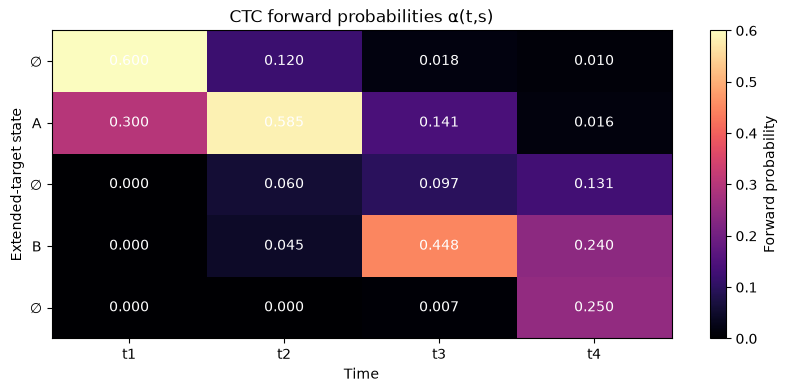

In [5]:
fig,ax=plt.subplots(figsize=(10,4))
im=ax.imshow(alpha.T,aspect="auto",cmap="magma")
for t in range(alpha.shape[0]):
    for s in range(alpha.shape[1]): ax.text(t,s,f"{alpha[t,s]:.3f}",ha="center",va="center",color="white")
ax.set(xticks=range(4),xticklabels=[f"t{i+1}" for i in range(4)],yticks=range(len(ext)),yticklabels=ext,
       xlabel="Time",ylabel="Extended-target state",title="CTC forward probabilities α(t,s)")
fig.colorbar(im,ax=ax,label="Forward probability"); plt.show()

## 4. 交互：逐列揭示动态规划表

In [6]:
@interact(step=IntSlider(min=1,max=4,value=1,description="已计算时间步"))
def reveal(step=1):
    shown=alpha[:step].T
    fig,ax=plt.subplots(figsize=(2+step*1.6,4))
    im=ax.imshow(shown,aspect="auto",cmap="magma",vmin=0,vmax=alpha.max())
    for s in range(shown.shape[0]):
        for t in range(shown.shape[1]): ax.text(t,s,f"{shown[s,t]:.3f}",ha="center",va="center",color="white")
    ax.set(xticks=range(step),xticklabels=[f"t{i+1}" for i in range(step)],yticks=range(len(ext)),yticklabels=ext)
    ax.set(title=f"Forward table through t={step}",xlabel="Time",ylabel="State"); plt.show()

interactive(children=(IntSlider(value=1, description='已计算时间步', max=4, min=1), Output()), _dom_classes=('widget…

## 5. 为什么要用 LogSumExp

路径概率是许多小数连乘，长语音会下溢成 0。在 log-space 中：乘法变加法，加法用 `logsumexp`。

In [7]:
tiny=np.float32(0.01)
print("float32 中 0.01^100 =",tiny**100)
def logsumexp(values):
    values=np.asarray(values,dtype=np.float64); m=values.max()
    return m+np.log(np.exp(values-m).sum())
a,b=np.log(1e-200),np.log(2e-200)
print("稳定 log(exp(a)+exp(b)) =",logsumexp([a,b]))
print("再 exp 回去 =",np.exp(logsumexp([a,b])))

float32 中 0.01^100 = 0.0
稳定 log(exp(a)+exp(b)) = -459.41840631014105
再 exp 回去 = 2.999999999999927e-200


## 本课测试

1. 目标长度为 $U$，扩展序列长度是多少？
2. 为什么某些状态可以跨两步？
3. 最终概率为什么取最后两个状态之和？
4. 动态规划复杂度大约是多少？
5. `logsumexp` 解决什么问题？

<details><summary>展开参考答案</summary>

1. $2U+1$。 2. 允许跳过 blank，但不能由此错误地产生相邻重复 token。 3. 路径可以结束在最后一个 token 或末尾 blank。 4. $O(TU)$，远小于枚举。 5. 防止许多小概率连乘产生数值下溢。

</details>

## 下一课

把手算结果交给 PyTorch：理解 `CTCLoss` 的每个 shape、length 与常见报错。

<!-- course-upgrade-v2 -->
## 强化练习：第 11 课专属题库

请先把答案写进新的 Markdown/Code cell，再展开自评标准。

### A. 基础回忆

1. 不看上文，分别定义 `扩展标签`、`前向动态规划`、`LogSumExp`。
2. 哪一个量/状态是本课最容易在模块边界丢失的？它的单位和 shape 是什么？
3. 本课至少写出两个“看起来能运行，但结果其实错误”的例子。

### B. 预测与推理

4. 场景：**长语音中直接连乘概率**。先预测现象，再说明原因，最后给出一项可以验证猜测的指标。
5. 改变本课最关键参数的 0.5×、1×、2×，分别预测准确率、延迟、内存或数值误差怎样变化。
6. 画一张最小数据流图，在每条边标出 dtype、shape、时间单位或概率/代价方向。

### C. 编程与排错

7. 编程任务：**用枚举验算 forward algorithm**。至少加入正常、边界、错误输入三类测试。
8. 故意制造一个 off-by-one、shape、状态未 reset 或数值稳定性错误；记录错误现象和定位过程。
9. 不看本课实现，从空白 cell 重写最核心函数，并用原实现作数值对照。

### D. 迁移与表达

10. 跨课任务：**连接动态规划总概率与 CTCLoss**。
11. 用 90 秒向没有学过 ASR 的人解释本课；禁止只念术语，必须举一个数字或生活例子。
12. 写出一个生产系统中会监控的指标，以及它异常时优先检查的三处位置。

<details><summary>展开自评标准</summary>

- 每题 0～2 分：0=无法回答；1=方向正确但缺少单位、边界或验证；2=解释完整且能用代码/数字验证。
- 24 分满分：达到 19 分再进入下一课；15～18 分次日重做错题；低于 15 分回看本课图和核心代码。
- 第 4 题必须包含“预测—原因—指标”，第 7～9 题必须真正运行测试，第 10 题必须明确上下游 contract。
- 核心答案至少应正确使用：扩展标签、前向动态规划、LogSumExp。

</details>


<!-- course-upgrade-v2 -->
## 间隔复习与离场票

### 离场票（现在完成）

- [ ] 我能不用笔记解释 扩展标签、前向动态规划、LogSumExp。
- [ ] 我能说出本课最常见的错误及其观测现象。
- [ ] 我能从空白重写一个核心函数，并通过至少 3 个测试。
- [ ] 我能说明本课对上一层和下一层接口的影响。

### 复习时间表

- **明天（5 分钟）**：闭卷写出三个核心概念和一个公式/shape。
- **7 天后（15 分钟）**：重做第 4、7、10 题，不运行原答案。
- **30 天后（20 分钟）**：从真实音频或随机张量重新构造一个最小实验。

把错题记录到根目录 `LEARNING_LOG.md`。不要只写“不会”，要写：原判断、证据、正确规则、下次检查动作。
